# XAI Analysis — Extended Models (SVM, KNN, MLP)
## Stability and Reliability of XAI in ML-Based Network Intrusion Detection Systems

**Datasets:** UNSW-NB15, NSL-KDD  
**Models:** SVM (RBF), KNN (k=7), MLP  
**XAI Methods:** SHAP, LIME  
**Stability Metrics:** Cosine Similarity, Jaccard@5, Spearman Rank, Sign Agreement  

---

This notebook extends the group's SHAP and LIME analysis — which covered Random Forest, XGBoost, Decision Tree, and Gradient Boosting — to three additional model architectures: SVM, KNN, and MLP. The same XAI methods, stability metrics, noise levels, and evaluation framework are used throughout so results are directly comparable.

MLP is evaluated on UNSW-NB15 only (NSL-KDD covered separately by Shrutika).

---

### Notebook Structure

| Section | Content |
|---------|---------|
| 0 | Dataset download |
| 1 | Data loading and preprocessing |
| 2 | Model training — SVM, KNN, MLP |
| 3 | SHAP and LIME analysis |
| 4 | SHAP vs LIME feature agreement |
| 5 | Stability analysis under perturbation |
| 6 | Summary |

## 0. Dataset Download

In [1]:
# Install dependencies if needed
!pip install shap lime scikit-learn xgboost tensorflow pandas numpy matplotlib seaborn scipy joblib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 13.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=0d3fa1e4eded7717ea963e69e36d97b0ea912bfbe3683232dc4c3bb5ea092eb6
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [3]:
import os
import urllib.request

DATASET_DIR = 'datasets'
os.makedirs(DATASET_DIR, exist_ok=True)
os.makedirs('results',   exist_ok=True)
os.makedirs('models',    exist_ok=True)

# NSL-KDD — auto downloaded
NSL_URLS = {
    'KDDTrain+.txt': 'https://raw.githubusercontent.com/HoaNP/NSL-KDD-DataSet/master/KDDTrain%2B.txt',
    'KDDTest+.txt':  'https://raw.githubusercontent.com/HoaNP/NSL-KDD-DataSet/master/KDDTest%2B.txt',
}

# UNSW-NB15 — place manually in datasets/
# Download from: https://research.unsw.edu.au/projects/unsw-nb15-dataset
UNSW_FILES = ['UNSW_NB15_training-set.csv', 'UNSW_NB15_testing-set.csv']

print("NSL-KDD:")
for name, url in NSL_URLS.items():
    dest = os.path.join(DATASET_DIR, name)
    if os.path.exists(dest):
        print(f"  [exists]   {name}  ({os.path.getsize(dest)/1e6:.1f} MB)")
    else:
        print(f"  [fetching] {name} ...", end=" ", flush=True)
        try:
            urllib.request.urlretrieve(url, dest)
            print(f"done ({os.path.getsize(dest)/1e6:.1f} MB)")
        except Exception as e:
            print(f"FAILED: {e}")

print("\nUNSW-NB15:")
missing_unsw = []
for name in UNSW_FILES:
    dest = os.path.join(DATASET_DIR, name)
    if os.path.exists(dest):
        print(f"  [found]    {name}  ({os.path.getsize(dest)/1e6:.1f} MB)")
    else:
        print(f"  [missing]  {name} — place in datasets/ before running Section 1")
        missing_unsw.append(name)

SKIP_UNSW = bool(missing_unsw)
if SKIP_UNSW:
    print("\nNote: UNSW-NB15 missing. MLP section and UNSW rows will be skipped.")
else:
    print("\nAll datasets ready.")

NSL-KDD:
  [exists]   KDDTrain+.txt  (19.1 MB)
  [exists]   KDDTest+.txt  (3.4 MB)

UNSW-NB15:
  [found]    UNSW_NB15_training-set.csv  (32.3 MB)
  [found]    UNSW_NB15_testing-set.csv  (15.4 MB)

All datasets ready.


## 1. Data Loading and Preprocessing

Data loading uses the same preprocessing pipeline as the group: label encoding for categorical features, StandardScaler normalisation, and an 80/20 stratified split for UNSW-NB15. NSL-KDD uses the pre-split train/test files.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import shap
import joblib
import time
import warnings
from scipy.stats import spearmanr
from sklearn.metrics.pairwise import cosine_similarity
from IPython.display import display, HTML

warnings.filterwarnings('ignore')
shap.initjs()

# Match group's plot style exactly
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

from sklearn.preprocessing   import LabelEncoder, StandardScaler
from sklearn.model_selection  import train_test_split
from sklearn.svm              import SVC
from sklearn.neighbors        import KNeighborsClassifier
from sklearn.base             import BaseEstimator, ClassifierMixin
from sklearn.metrics          import (accuracy_score, precision_score,
                                      recall_score, f1_score, confusion_matrix)
from lime.lime_tabular        import LimeTabularExplainer

import tensorflow as tf
from tensorflow.keras.models     import Sequential
from tensorflow.keras.layers     import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks  import EarlyStopping


PALETTE    = sns.color_palette('Set2', 3)
MY_MODELS  = ['SVM', 'KNN', 'MLP']
DATASETS   = ['UNSW-NB15', 'NSL-KDD']
TOP_K      = 10

print('Setup complete.')

Setup complete.


In [5]:
def load_unsw():
    df = pd.read_csv('datasets/UNSW_NB15_training-set.csv')
    drop_cols = [c for c in ['id', 'attack_cat', 'label'] if c in df.columns]
    cat_cols  = [c for c in df.select_dtypes('object').columns if c != 'label']
    for c in cat_cols:
        le = LabelEncoder()
        df[c] = le.fit_transform(df[c].astype(str))
    X = df.drop(drop_cols, axis=1)
    y = df['label']
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y)
    sc   = StandardScaler()
    X_tr = pd.DataFrame(sc.fit_transform(X_tr), columns=X.columns)
    X_te = pd.DataFrame(sc.transform(X_te),     columns=X.columns)
    return X_tr, X_te, y_tr.reset_index(drop=True), y_te.reset_index(drop=True), sc


def load_nslkdd():
    cols = [
        'duration','protocol_type','service','flag','src_bytes','dst_bytes',
        'land','wrong_fragment','urgent','hot','num_failed_logins','logged_in',
        'num_compromised','root_shell','su_attempted','num_root',
        'num_file_creations','num_shells','num_access_files','num_outbound_cmds',
        'is_host_login','is_guest_login','count','srv_count','serror_rate',
        'srv_serror_rate','rerror_rate','srv_rerror_rate','same_srv_rate',
        'diff_srv_rate','srv_diff_host_rate','dst_host_count','dst_host_srv_count',
        'dst_host_same_srv_rate','dst_host_diff_srv_rate',
        'dst_host_same_src_port_rate','dst_host_srv_diff_host_rate',
        'dst_host_serror_rate','dst_host_srv_serror_rate',
        'dst_host_rerror_rate','dst_host_srv_rerror_rate','label','difficulty'
    ]
    tr = pd.read_csv('datasets/KDDTrain+.txt', header=None, names=cols)
    te = pd.read_csv('datasets/KDDTest+.txt',  header=None, names=cols)
    for df in [tr, te]:
        df['label'] = (df['label'] != 'normal').astype(int)
    for c in ['protocol_type', 'service', 'flag']:
        le = LabelEncoder()
        tr[c] = le.fit_transform(tr[c])
        te[c] = te[c].map(lambda x: x if x in le.classes_ else le.classes_[0])
        te[c] = le.transform(te[c])
    X_tr = tr.drop(['label','difficulty'], axis=1)
    X_te = te.drop(['label','difficulty'], axis=1)
    sc   = StandardScaler()
    X_tr = pd.DataFrame(sc.fit_transform(X_tr), columns=X_tr.columns)
    X_te = pd.DataFrame(sc.transform(X_te),     columns=X_te.columns)
    return (X_tr, X_te,
            tr['label'].reset_index(drop=True),
            te['label'].reset_index(drop=True), sc)


datasets = {}
if not SKIP_UNSW:
    datasets['UNSW-NB15'] = load_unsw()
    print(f"UNSW-NB15  train={datasets['UNSW-NB15'][0].shape}  test={datasets['UNSW-NB15'][1].shape}")

datasets['NSL-KDD'] = load_nslkdd()
print(f"NSL-KDD    train={datasets['NSL-KDD'][0].shape}  test={datasets['NSL-KDD'][1].shape}")

active_datasets = list(datasets.keys())

UNSW-NB15  train=(140272, 42)  test=(35069, 42)
NSL-KDD    train=(125973, 41)  test=(22544, 41)


## 2. Model Training

Three models are trained on both datasets. SVM and KNN use subsamples of the training set for speed. All models are cached to `models/` and reloaded on subsequent runs.

| Model | Configuration |
|-------|--------------|
| SVM | RBF kernel, C=1.0, γ=scale, 20k training subsample |
| KNN | k=7, distance-weighted, Euclidean, 30k training subsample |
| MLP | 256→128→64→1, BatchNorm, Dropout, early stopping |

In [6]:
# Keras wrapper — lets sklearn-style scorers and LIME call the MLP
class KerasWrapper(BaseEstimator, ClassifierMixin):
    def __init__(self, model):
        self.model = model
    def fit(self, X, y):
        return self
    def predict(self, X):
        return (self.model.predict(np.array(X), verbose=0).flatten() > 0.5).astype(int)
    def predict_proba(self, X):
        p = self.model.predict(np.array(X), verbose=0).flatten()
        return np.column_stack([1 - p, p])

In [7]:
trained_models = {}
perf_rows      = []
mlp_histories  = {}

for ds_name, (X_tr, X_te, y_tr, y_te, _) in datasets.items():
    n_feat = X_tr.shape[1]
    print(f'\n{ds_name}')
    print('-' * 40)

    # SVM
    rng   = np.random.RandomState(42)
    idx   = rng.choice(len(X_tr), min(20_000, len(X_tr)), replace=False)
    cache = f'models/{ds_name}_SVM.pkl'
    if os.path.exists(cache):
        svm = joblib.load(cache); t = 0.0
    else:
        svm = SVC(kernel='rbf', C=1.0, gamma='scale',
                  probability=True, random_state=42, cache_size=500)
        t0  = time.time()
        svm.fit(X_tr.iloc[idx], y_tr.iloc[idx])
        t   = time.time() - t0
        joblib.dump(svm, cache)
    trained_models[(ds_name, 'SVM')] = svm
    preds = svm.predict(X_te)
    perf_rows.append({
        'Dataset': ds_name, 'Model': 'SVM',
        'Accuracy':  round(accuracy_score(y_te, preds), 4),
        'Precision': round(precision_score(y_te, preds, zero_division=0), 4),
        'Recall':    round(recall_score(y_te, preds, zero_division=0), 4),
        'F1-Score':  round(f1_score(y_te, preds, zero_division=0), 4),
        'Train Time (s)': round(t, 2),
    })
    print(f'  SVM   F1={perf_rows[-1]["F1-Score"]:.4f}  ({t:.1f}s)')

    # KNN
    rng   = np.random.RandomState(0)
    idx   = rng.choice(len(X_tr), min(30_000, len(X_tr)), replace=False)
    cache = f'models/{ds_name}_KNN.pkl'
    if os.path.exists(cache):
        knn = joblib.load(cache); t = 0.0
    else:
        knn = KNeighborsClassifier(n_neighbors=7, weights='distance',
                                   metric='euclidean', n_jobs=-1)
        t0  = time.time()
        knn.fit(X_tr.iloc[idx], y_tr.iloc[idx])
        t   = time.time() - t0
        joblib.dump(knn, cache)
    trained_models[(ds_name, 'KNN')] = knn
    preds = knn.predict(X_te)
    perf_rows.append({
        'Dataset': ds_name, 'Model': 'KNN',
        'Accuracy':  round(accuracy_score(y_te, preds), 4),
        'Precision': round(precision_score(y_te, preds, zero_division=0), 4),
        'Recall':    round(recall_score(y_te, preds, zero_division=0), 4),
        'F1-Score':  round(f1_score(y_te, preds, zero_division=0), 4),
        'Train Time (s)': round(t, 2),
    })
    print(f'  KNN   F1={perf_rows[-1]["F1-Score"]:.4f}  ({t:.1f}s)')

    # MLP — UNSW-NB15 only (NSL-KDD covered by the group)
    if ds_name == 'UNSW-NB15':
        cache = f'models/{ds_name}_MLP.keras'
        if os.path.exists(cache):
            mlp = tf.keras.models.load_model(cache); t = 0.0
        else:
            mlp = Sequential([
                Dense(256, activation='relu', input_shape=(n_feat,)),
                BatchNormalization(), Dropout(0.3),
                Dense(128, activation='relu'),
                BatchNormalization(), Dropout(0.3),
                Dense(64,  activation='relu'), Dropout(0.2),
                Dense(1,   activation='sigmoid'),
            ])
            mlp.compile(optimizer=Adam(1e-3),
                        loss='binary_crossentropy', metrics=['accuracy'])
            es   = EarlyStopping(monitor='val_loss', patience=3,
                                 restore_best_weights=True)
            t0   = time.time()
            hist = mlp.fit(X_tr, y_tr, epochs=20, batch_size=256,
                           validation_split=0.1, callbacks=[es], verbose=0)
            t    = time.time() - t0
            mlp.save(cache)
            mlp_histories[ds_name] = hist.history
        trained_models[(ds_name, 'MLP')] = mlp
        preds = (mlp.predict(X_te, verbose=0).flatten() > 0.5).astype(int)
        perf_rows.append({
            'Dataset': ds_name, 'Model': 'MLP',
            'Accuracy':  round(accuracy_score(y_te, preds), 4),
            'Precision': round(precision_score(y_te, preds, zero_division=0), 4),
            'Recall':    round(recall_score(y_te, preds, zero_division=0), 4),
            'F1-Score':  round(f1_score(y_te, preds, zero_division=0), 4),
            'Train Time (s)': round(t, 2),
        })
        print(f'  MLP   F1={perf_rows[-1]["F1-Score"]:.4f}  ({t:.1f}s)')

perf_df = pd.DataFrame(perf_rows)
perf_df.to_csv('results/extended_model_performance.csv', index=False)


UNSW-NB15
----------------------------------------
  SVM   F1=0.9559  (26.8s)
  KNN   F1=0.9548  (0.0s)
  MLP   F1=0.9601  (39.9s)

NSL-KDD
----------------------------------------
  SVM   F1=0.7666  (11.2s)
  KNN   F1=0.7559  (0.0s)


### 2.1 MLP Training Curves

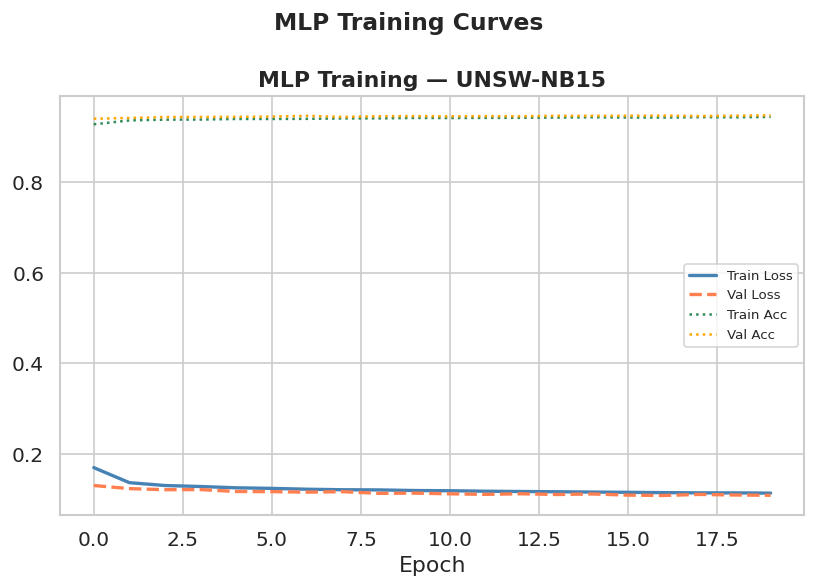

In [8]:
if mlp_histories:
    fig, axes = plt.subplots(1, len(mlp_histories), figsize=(7 * len(mlp_histories), 5))
    if len(mlp_histories) == 1:
        axes = [axes]
    for ax, (ds_name, h) in zip(axes, mlp_histories.items()):
        ax.plot(h['loss'],         label='Train Loss',  color='steelblue', lw=2)
        ax.plot(h['val_loss'],     label='Val Loss',    color='coral',     lw=2, ls='--')
        ax.plot(h['accuracy'],     label='Train Acc',   color='seagreen',  lw=1.5, ls=':')
        ax.plot(h['val_accuracy'], label='Val Acc',     color='orange',    lw=1.5, ls=':')
        ax.set_title(f'MLP Training — {ds_name}', fontweight='bold')
        ax.set_xlabel('Epoch')
        ax.legend(fontsize=8)
    fig.suptitle('MLP Training Curves', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('results/extended_mlp_training_curves.png',
                bbox_inches='tight', dpi=120)
    plt.show()

### 2.2 Performance Table

In [9]:
display(HTML('<h4>Model Performance — SVM, KNN, MLP</h4>'))
display(perf_df.style
    .background_gradient(cmap='YlGnBu',
                         subset=['Accuracy','Precision','Recall','F1-Score'])
    .format({'Accuracy':'{:.4f}','Precision':'{:.4f}',
             'Recall':'{:.4f}','F1-Score':'{:.4f}',
             'Train Time (s)':'{:.2f}'}))

,Dataset,Model,Accuracy,Precision,Recall,F1-Score,Train Time (s)
0,UNSW-NB15,SVM,0.9375,0.9187,0.9963,0.9559,26.82
1,UNSW-NB15,KNN,0.9377,0.9431,0.9668,0.9548,0.02
2,UNSW-NB15,MLP,0.9451,0.9490,0.9715,0.9601,39.94
3,NSL-KDD,SVM,0.7812,0.9760,0.6312,0.7666,11.17
4,NSL-KDD,KNN,0.7724,0.9701,0.6192,0.7559,0.02


### 2.3 Performance Bar Chart

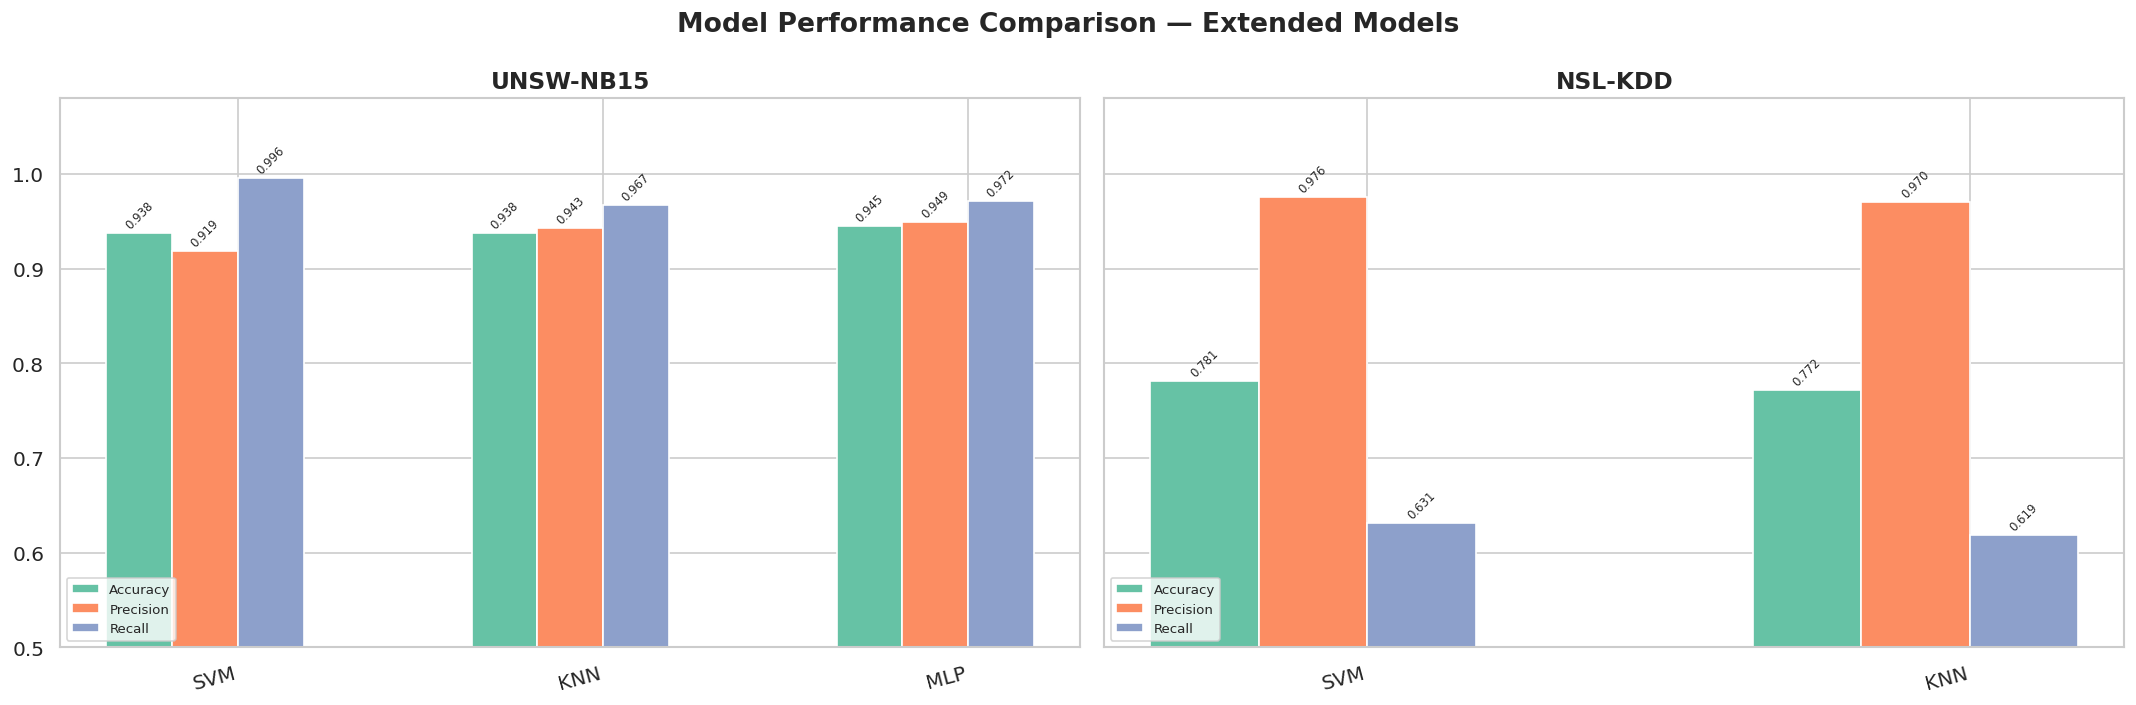

In [10]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
fig, axes = plt.subplots(1, len(active_datasets), figsize=(9 * len(active_datasets), 6), sharey=True)
if len(active_datasets) == 1:
    axes = [axes]

for ax, ds in zip(axes, active_datasets):
    models_in_ds = [m for m in MY_MODELS
                    if (ds, m) in trained_models]
    sub = perf_df[perf_df['Dataset'] == ds].set_index('Model').loc[models_in_ds]
    x, w = np.arange(len(models_in_ds)), 0.18
    for i, (m, c) in enumerate(zip(metrics, PALETTE)):
        bars = ax.bar(x + i*w, sub[m], w, label=m,
                      color=sns.color_palette('Set2', 4)[i])
        for j, v in enumerate(sub[m]):
            ax.text(x[j]+i*w, v+0.005, f'{v:.3f}',
                    ha='center', fontsize=7, rotation=45)
    ax.set_xticks(x + 1.5*w)
    ax.set_xticklabels(models_in_ds, rotation=15, ha='right')
    ax.set_ylim(0.5, 1.08)
    ax.set_title(ds, fontsize=14, fontweight='bold')
    ax.legend(fontsize=8, loc='lower left')

fig.suptitle('Model Performance Comparison — Extended Models', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('results/extended_performance_bars.png', bbox_inches='tight', dpi=120)
plt.show()

### 2.4 Confusion Matrices

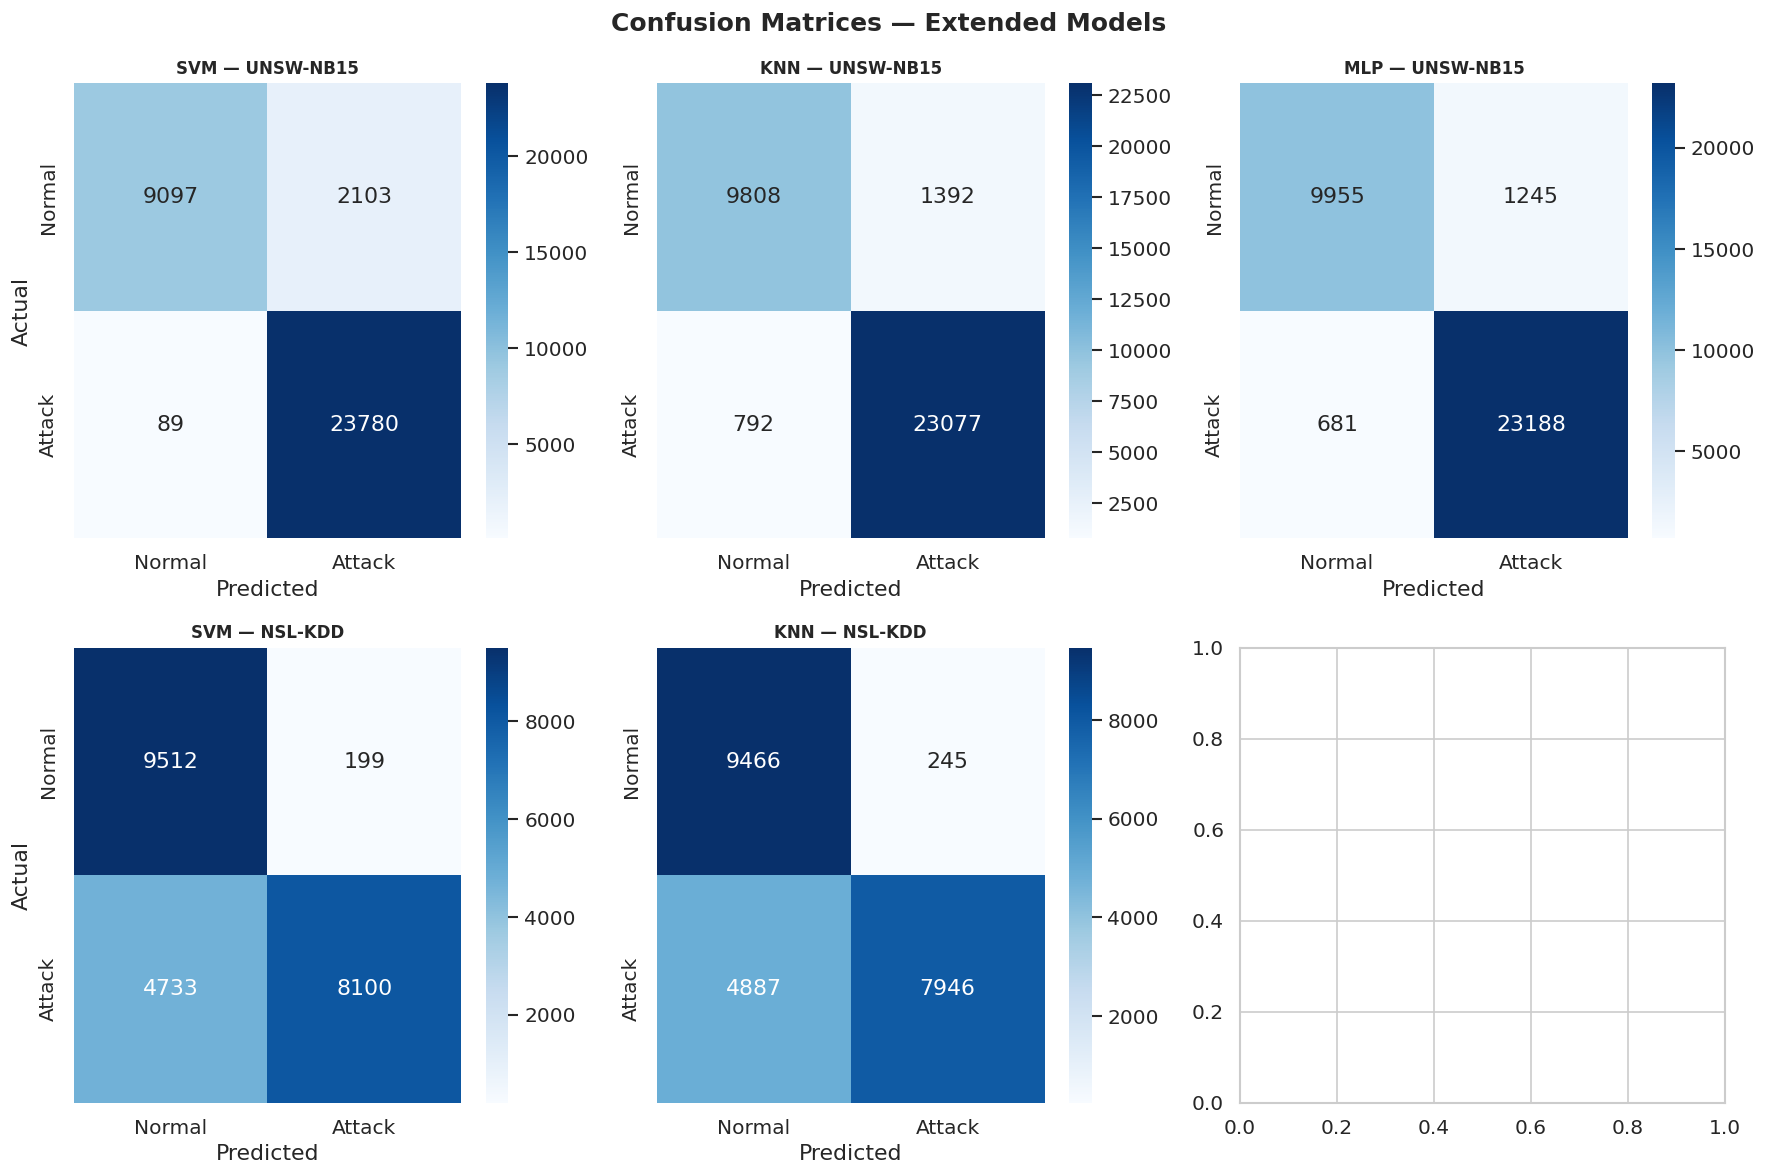

In [11]:
n_cols = max(len([m for m in MY_MODELS if (ds, m) in trained_models])
              for ds in active_datasets)
fig, axes = plt.subplots(len(active_datasets), n_cols,
                         figsize=(5 * n_cols, 5 * len(active_datasets)))
if len(active_datasets) == 1:
    axes = axes[np.newaxis, :]

for row, ds in enumerate(active_datasets):
    _, X_te, _, y_te, _ = datasets[ds]
    models_in_ds = [m for m in MY_MODELS if (ds, m) in trained_models]
    for col, mn in enumerate(models_in_ds):
        ax  = axes[row][col]
        mdl = trained_models[(ds, mn)]
        if mn == 'MLP':
            preds = (mdl.predict(X_te, verbose=0).flatten() > 0.5).astype(int)
        else:
            preds = mdl.predict(X_te)
        cm = confusion_matrix(y_te, preds)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                    xticklabels=['Normal','Attack'],
                    yticklabels=['Normal','Attack'])
        ax.set_title(f'{mn} — {ds}', fontsize=10, fontweight='bold')
        ax.set_ylabel('Actual'    if col == 0 else '')
        ax.set_xlabel('Predicted')

fig.suptitle('Confusion Matrices — Extended Models', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('results/extended_confusion_matrices.png', bbox_inches='tight', dpi=120)
plt.show()

## 3. SHAP and LIME Analysis

SHAP and LIME are applied to SVM, KNN, and MLP using the same sample sizes, `TOP_K`, and agreement metrics as the group's analysis of tree models. KernelExplainer is used for all three models since TreeExplainer requires a tree-based architecture.

In [12]:
SAMPLE_SIZE = 200
agreement_results = []

for ds_name in active_datasets:
    X_train, X_test, y_train, y_test, _ = datasets[ds_name]
    feature_names = X_train.columns.tolist()
    X_sample = X_test.sample(min(SAMPLE_SIZE, len(X_test)), random_state=42)

    models_in_ds = [m for m in MY_MODELS if (ds_name, m) in trained_models]

    for model_name in models_in_ds:
        model = trained_models[(ds_name, model_name)]
        print(f'\n--- {model_name} on {ds_name} ---')

        # predict_proba wrapper
        if model_name == 'MLP':
            wrapped = KerasWrapper(model)
            predict_fn = lambda x: wrapped.predict_proba(x)
        else:
            predict_fn = lambda x, m=model, f=feature_names: m.predict_proba(
                pd.DataFrame(x, columns=f))

        # SHAP — KernelExplainer (model-agnostic)
        t0 = time.time()
        bg = shap.sample(X_train, 100, random_state=42)
        X_kern = X_test.sample(min(50, len(X_test)), random_state=42)
        ke = shap.KernelExplainer(
            lambda x: predict_fn(x)[:, 1], bg)
        shap_vals = ke.shap_values(X_kern, nsamples=100)
        shap_time = time.time() - t0
        shap_importance = np.abs(shap_vals).mean(axis=0).flatten()
        shap_top = [feature_names[int(i)]
                    for i in np.argsort(shap_importance)[::-1][:TOP_K]]

        # LIME
        t0 = time.time()
        lime_exp = LimeTabularExplainer(
            X_train.values, feature_names=feature_names,
            class_names=['Normal','Attack'], mode='classification')
        lime_importance = np.zeros(len(feature_names))
        n_lime = min(50, len(X_sample))
        for i in range(n_lime):
            exp = lime_exp.explain_instance(
                X_sample.iloc[i].values, predict_fn,
                num_features=TOP_K)
            for feat_str, weight in exp.as_list():
                for fi, fn in enumerate(feature_names):
                    if fn in feat_str:
                        lime_importance[fi] += abs(weight)
        lime_importance /= n_lime
        lime_time = time.time() - t0
        lime_top = [feature_names[int(i)]
                    for i in np.argsort(lime_importance)[::-1][:TOP_K]]

        overlap = len(set(shap_top) & set(lime_top))
        jaccard = overlap / len(set(shap_top) | set(lime_top))
        sp_corr, _ = spearmanr(
            np.argsort(np.argsort(-shap_importance.flatten())),
            np.argsort(np.argsort(-lime_importance.flatten()))
        )

        agreement_results.append({
            'Dataset':       ds_name,
            'Model':         model_name,
            'Top-10 Overlap': overlap,
            'Jaccard':       round(jaccard, 4),
            'Spearman':      round(sp_corr, 4),
            'SHAP Time (s)': round(shap_time, 2),
            'LIME Time (s)': round(lime_time, 2),
            '_shap_imp':     shap_importance,
            '_lime_imp':     lime_importance,
            '_shap_vals':    shap_vals,
            '_X_sample':     X_kern,
        })
        print(f'  SHAP: {shap_time:.1f}s | LIME: {lime_time:.1f}s | Overlap: {overlap}/{TOP_K}')

agree_df = pd.DataFrame([{k: v for k, v in r.items()
                           if not k.startswith('_')}
                          for r in agreement_results])
display(HTML('<h4>SHAP vs LIME Feature Agreement</h4>'))
display(agree_df)
agree_df.to_csv('results/extended_xai_agreement.csv', index=False)


--- SVM on UNSW-NB15 ---


  0%|          | 0/50 [00:00<?, ?it/s]

  SHAP: 127.9s | LIME: 69.4s | Overlap: 7/10

--- KNN on UNSW-NB15 ---


  0%|          | 0/50 [00:00<?, ?it/s]

  SHAP: 98.8s | LIME: 56.2s | Overlap: 6/10

--- MLP on UNSW-NB15 ---


  0%|          | 0/50 [00:00<?, ?it/s]

  SHAP: 40.0s | LIME: 27.4s | Overlap: 6/10

--- SVM on NSL-KDD ---


  0%|          | 0/50 [00:00<?, ?it/s]

  SHAP: 64.6s | LIME: 31.6s | Overlap: 0/10

--- KNN on NSL-KDD ---


  0%|          | 0/50 [00:00<?, ?it/s]

  SHAP: 99.3s | LIME: 55.7s | Overlap: 2/10


,Dataset,Model,Top-10 Overlap,Jaccard,Spearman,SHAP Time (s),LIME Time (s)
0,UNSW-NB15,SVM,7,0.5385,0.2381,127.94,69.45
1,UNSW-NB15,KNN,6,0.4286,0.4364,98.83,56.20
2,UNSW-NB15,MLP,6,0.4286,0.3578,39.97,27.40
3,NSL-KDD,SVM,0,0.0000,-0.5328,64.58,31.61
4,NSL-KDD,KNN,2,0.1111,-0.3120,99.26,55.71


## 4. SHAP vs LIME Feature Agreement

### 4.1 SHAP Summary Plots

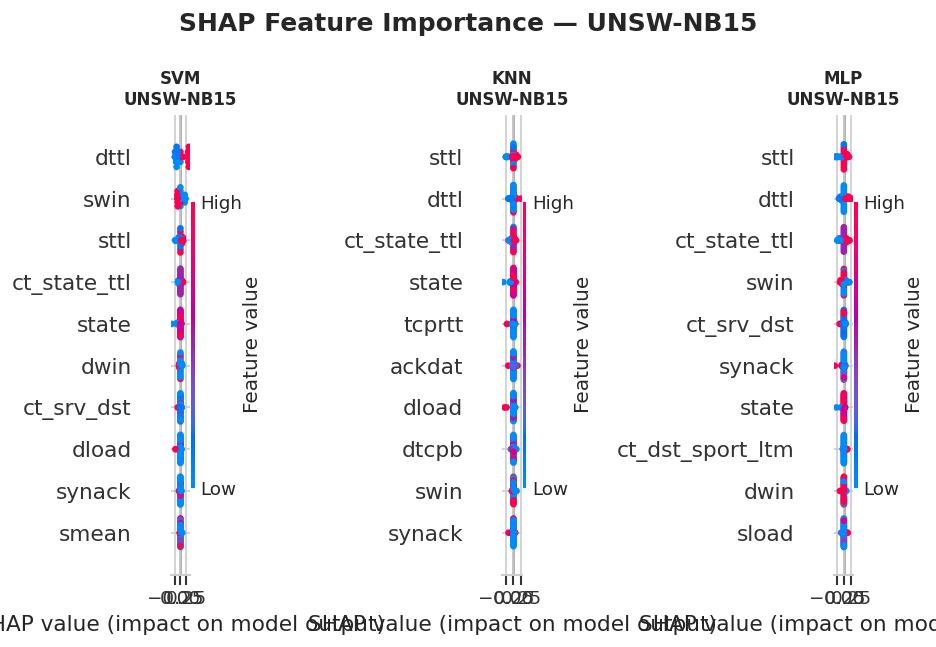

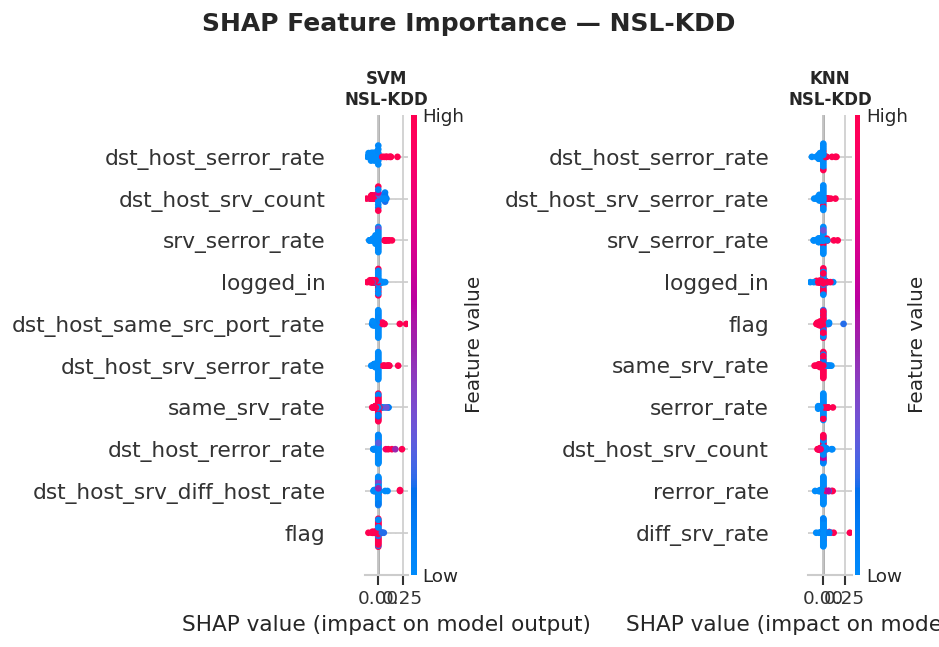

In [13]:
for ds_name in active_datasets:
    models_in_ds = [r for r in agreement_results if r['Dataset'] == ds_name]
    n = len(models_in_ds)
    fig, axes = plt.subplots(1, n, figsize=(9 * n, 6))
    if n == 1:
        axes = [axes]

    for ax, r in zip(axes, models_in_ds):
        plt.sca(ax)
        shap.summary_plot(r['_shap_vals'], r['_X_sample'],
                          plot_type='dot', max_display=10, show=False)
        ax.set_title(f'{r["Model"]}\n{ds_name}', fontsize=10, fontweight='bold')

    fig.suptitle(f'SHAP Feature Importance — {ds_name}',
                 fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'results/extended_shap_summary_{ds_name.replace("-","_")}.png',
                bbox_inches='tight', dpi=120)
    plt.show()

### 4.2 Agreement Metrics Comparison

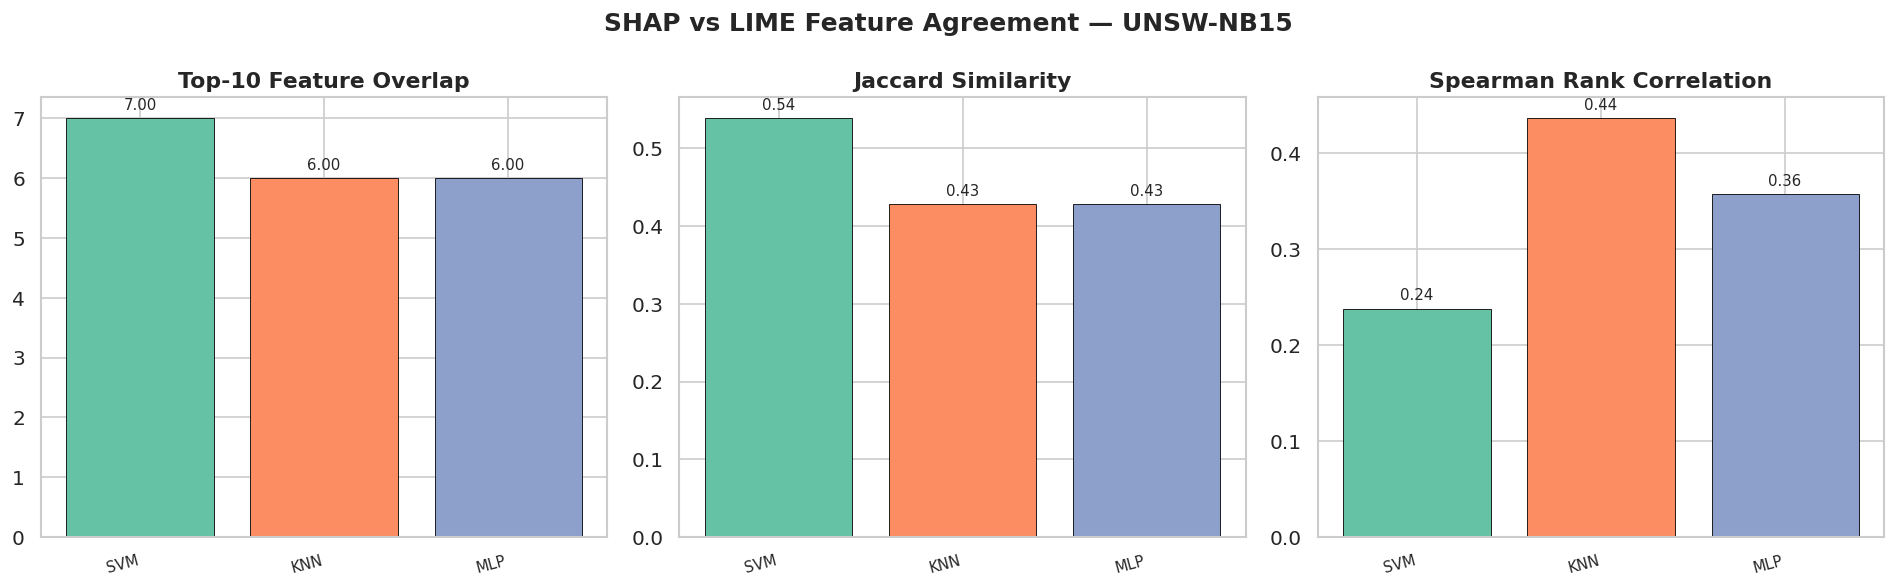

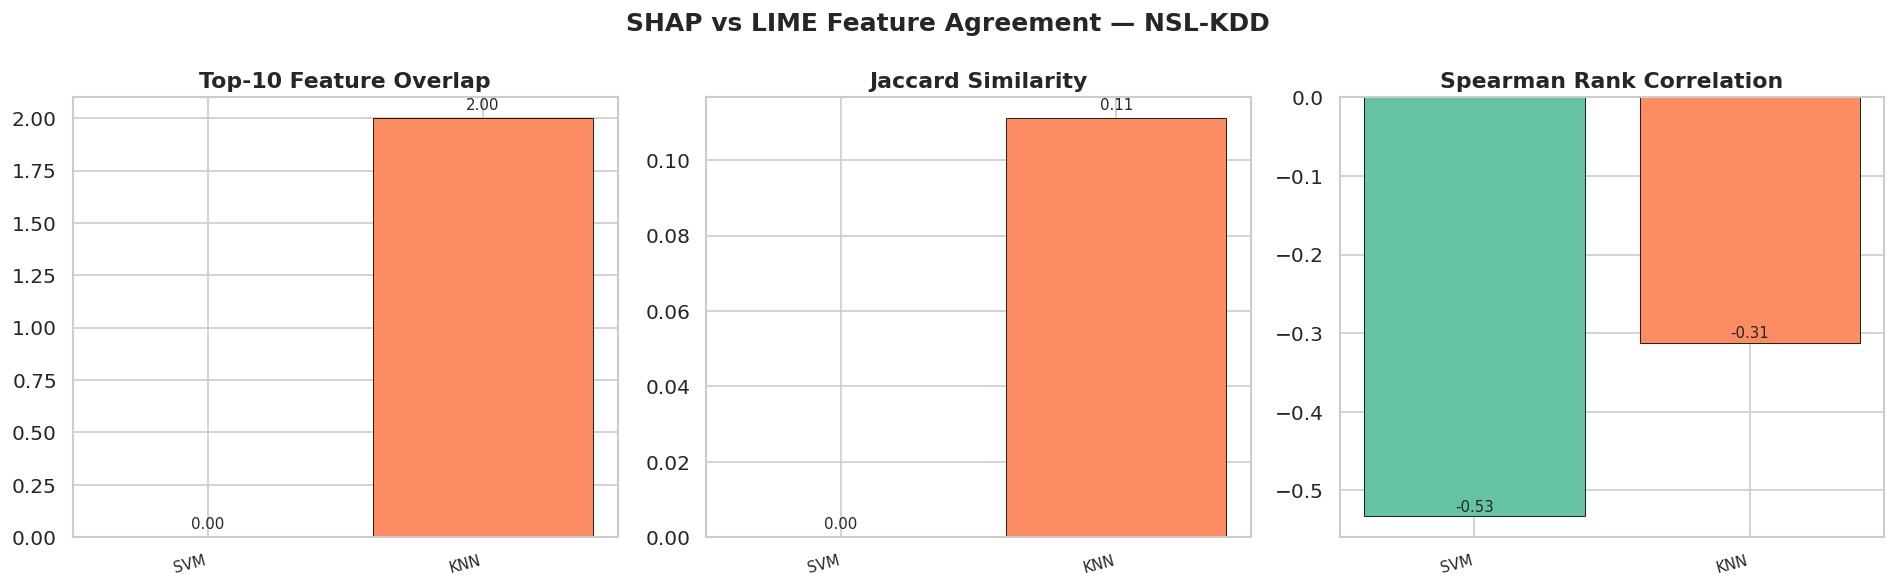

In [14]:
for ds_name in active_datasets:
    sub = agree_df[agree_df['Dataset'] == ds_name]
    if sub.empty:
        continue

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    for ax, (metric, title) in zip(axes, [
        ('Top-10 Overlap', 'Top-10 Feature Overlap'),
        ('Jaccard',        'Jaccard Similarity'),
        ('Spearman',       'Spearman Rank Correlation'),
    ]):
        models_in_sub = sub['Model'].tolist()
        colors = sns.color_palette('Set2', len(models_in_sub))
        bars = ax.bar(models_in_sub, sub[metric], color=colors,
                      edgecolor='black', linewidth=0.5)
        for b, v in zip(bars, sub[metric]):
            ax.text(b.get_x() + b.get_width()/2,
                    b.get_height() + abs(sub[metric].max()) * 0.02,
                    f'{v:.2f}', ha='center', fontsize=9)
        ax.set_title(title, fontweight='bold')
        ax.set_xticklabels(models_in_sub, rotation=15, ha='right', fontsize=9)
        ax.axhline(y=0, color='black', linewidth=0.5, linestyle='--')

    fig.suptitle(f'SHAP vs LIME Feature Agreement — {ds_name}',
                 fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'results/extended_agreement_{ds_name.replace("-","_")}.png',
                bbox_inches='tight', dpi=120)
    plt.show()

### 4.3 Side-by-Side Feature Importance: SHAP vs LIME

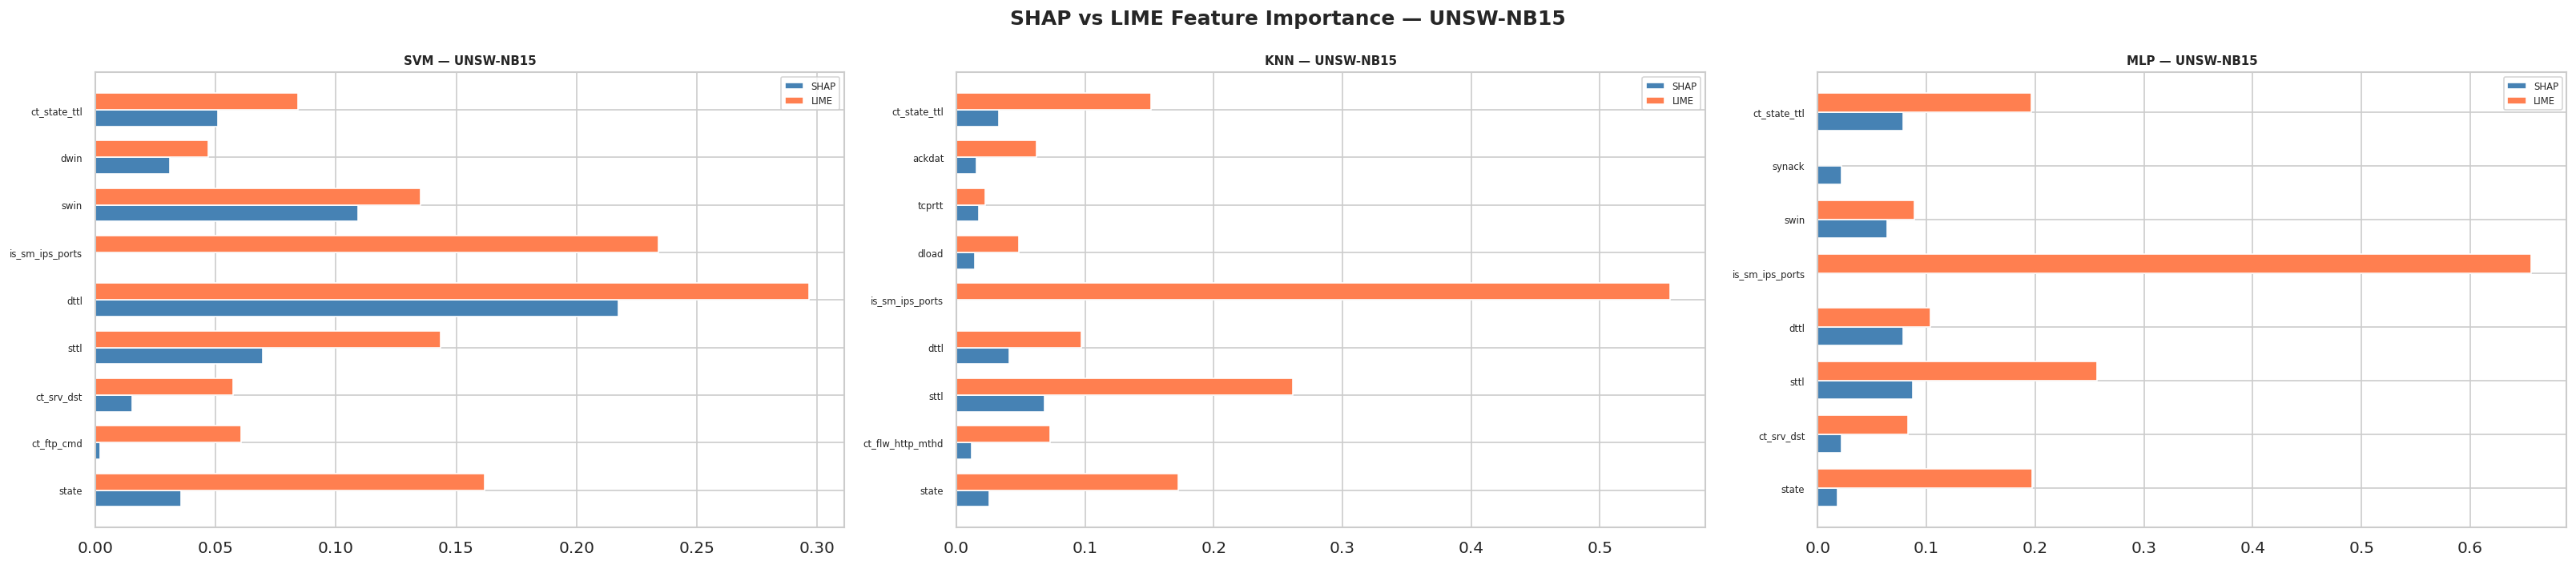

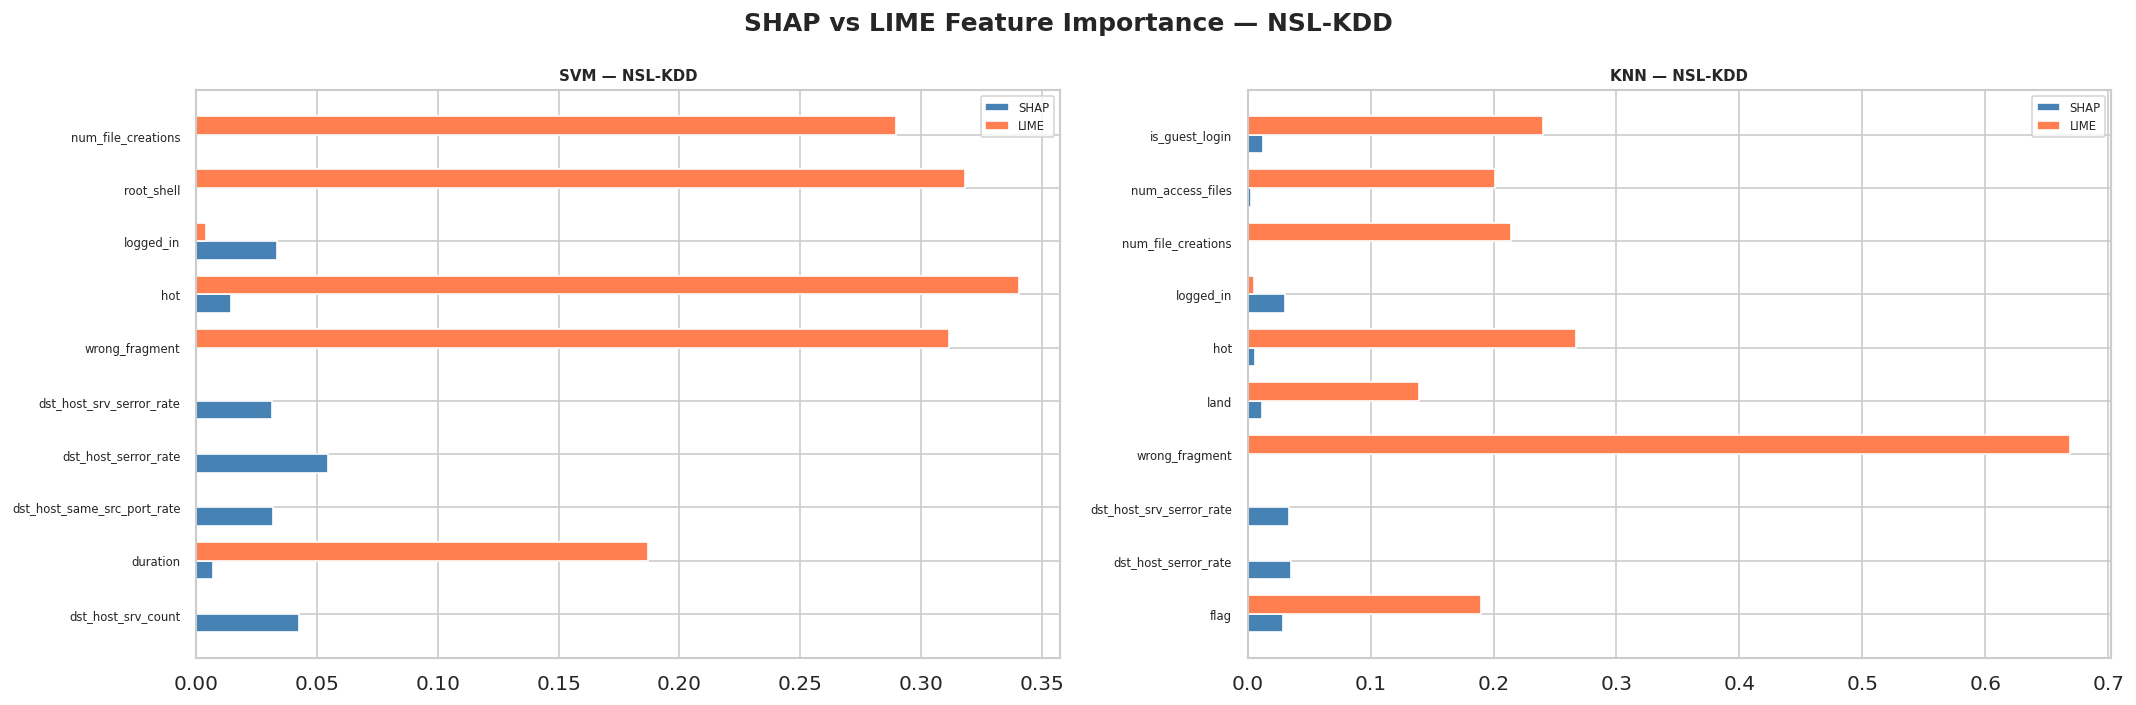

In [15]:
for ds_name in active_datasets:
    results_ds = [r for r in agreement_results if r['Dataset'] == ds_name]
    n = len(results_ds)
    fig, axes = plt.subplots(1, n, figsize=(9 * n, 6))
    if n == 1:
        axes = [axes]

    for ax, r in zip(axes, results_ds):
        fnames = datasets[ds_name][0].columns.tolist()
        si, li = r['_shap_imp'], r['_lime_imp']
        top_idx = list(set(
            list(np.argsort(si)[::-1][:7]) +
            list(np.argsort(li)[::-1][:7])
        ))[:10]
        names = [fnames[int(i)] for i in top_idx]
        x, w  = np.arange(len(names)), 0.35
        ax.barh(x - w/2, [si[i] for i in top_idx], w,
                label='SHAP', color='steelblue')
        ax.barh(x + w/2, [li[i] for i in top_idx], w,
                label='LIME', color='coral')
        ax.set_yticks(x)
        ax.set_yticklabels(names, fontsize=7)
        ax.set_title(f'{r["Model"]} — {ds_name}', fontsize=9, fontweight='bold')
        ax.legend(fontsize=7)

    fig.suptitle(f'SHAP vs LIME Feature Importance — {ds_name}',
                 fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'results/extended_shap_lime_bars_{ds_name.replace("-","_")}.png',
                bbox_inches='tight', dpi=120)
    plt.show()

### 4.4 XAI Runtime Comparison

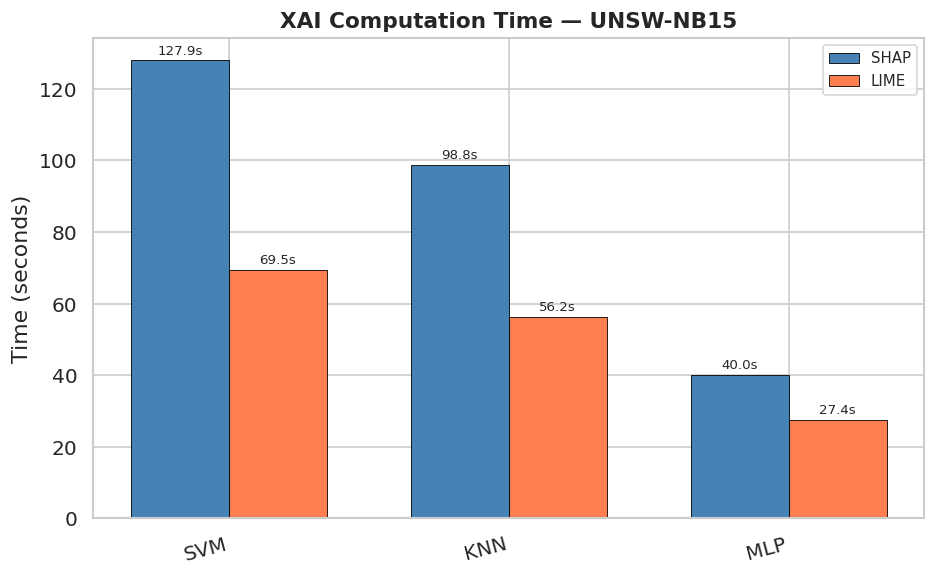

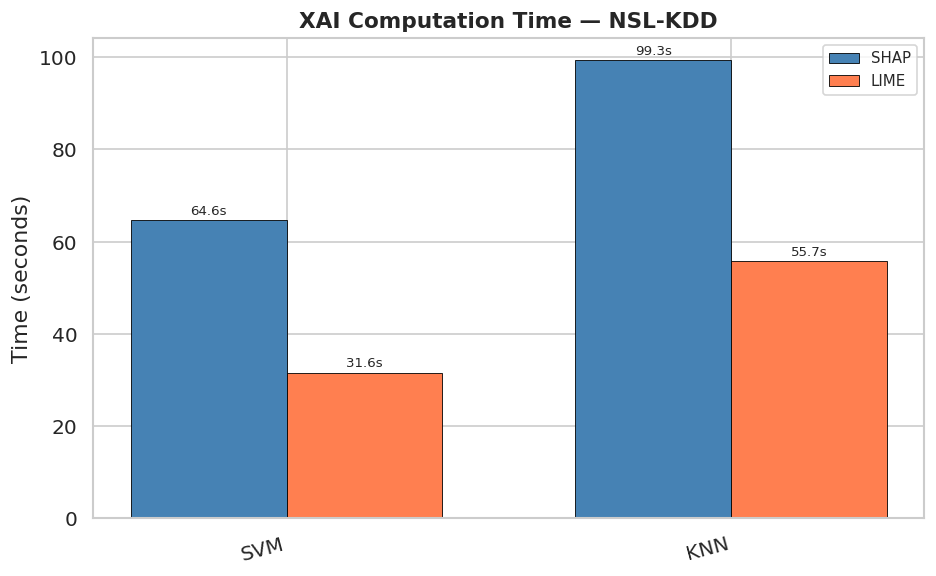

In [16]:
for ds_name in active_datasets:
    sub = agree_df[agree_df['Dataset'] == ds_name]
    if sub.empty:
        continue

    models_in_sub = sub['Model'].tolist()
    x   = np.arange(len(models_in_sub))
    w   = 0.35
    fig, ax = plt.subplots(figsize=(8, 5))
    b1 = ax.bar(x - w/2, sub['SHAP Time (s)'], w,
                label='SHAP', color='steelblue', edgecolor='black', linewidth=0.5)
    b2 = ax.bar(x + w/2, sub['LIME Time (s)'], w,
                label='LIME', color='coral',     edgecolor='black', linewidth=0.5)
    ax.bar_label(b1, fmt='%.1fs', fontsize=8, padding=2)
    ax.bar_label(b2, fmt='%.1fs', fontsize=8, padding=2)
    ax.set_xticks(x)
    ax.set_xticklabels(models_in_sub, rotation=15, ha='right')
    ax.set_ylabel('Time (seconds)')
    ax.set_title(f'XAI Computation Time — {ds_name}', fontweight='bold', fontsize=13)
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.savefig(f'results/extended_xai_runtime_{ds_name.replace("-","_")}.png',
                bbox_inches='tight', dpi=120)
    plt.show()

## 5. Stability Analysis

Explanation stability is evaluated using the same perturbation framework as the group: Gaussian noise at levels σ ∈ {0.01, 0.02, 0.05, 0.10} is added to test samples, and SHAP and LIME attributions are computed on the original and perturbed inputs.

The same four stability metrics are recorded: Cosine Similarity, Jaccard@5, Spearman Rank Correlation, and Sign Agreement.

In [17]:
NOISE_LEVELS = [0.01, 0.02, 0.05, 0.10]
N_SHAP       = 50
N_LIME       = 15
TOP_K_STAB   = 5

def compute_stability(v1, v2):
    v1, v2 = np.array(v1).flatten(), np.array(v2).flatten()
    n1, n2 = np.linalg.norm(v1), np.linalg.norm(v2)
    cos  = cosine_similarity(v1.reshape(1,-1),
                              v2.reshape(1,-1))[0][0]            if n1 > 0 and n2 > 0 else 1.0
    t1   = set(np.argsort(np.abs(v1))[::-1][:TOP_K_STAB])
    t2   = set(np.argsort(np.abs(v2))[::-1][:TOP_K_STAB])
    jac  = len(t1 & t2) / max(len(t1 | t2), 1)
    sp   = spearmanr(v1, v2)[0]            if np.std(v1) > 0 and np.std(v2) > 0 else 1.0
    s1, s2 = np.sign(v1), np.sign(v2)
    nz   = (s1 != 0) | (s2 != 0)
    sign = (s1[nz] == s2[nz]).mean() if nz.sum() > 0 else 1.0
    return cos, jac, sp, sign


def lime_vec(exp, fnames):
    v = np.zeros(len(fnames))
    for s, w in exp.as_list():
        for i, fn in enumerate(fnames):
            if fn in s:
                v[i] = w
    return v


stab_results = []

for ds_name in active_datasets:
    X_train, X_test, y_train, y_test, _ = datasets[ds_name]
    fnames = X_train.columns.tolist()

    models_in_ds = [m for m in MY_MODELS
                    if (ds_name, m) in trained_models]

    for mn in models_in_ds:
        model = trained_models[(ds_name, mn)]

        if mn == 'MLP':
            wrapped    = KerasWrapper(model)
            predict_fn = lambda x: wrapped.predict_proba(x)
        else:
            predict_fn = lambda x, m=model, f=fnames: m.predict_proba(
                pd.DataFrame(x, columns=f))

        bg       = shap.sample(X_train, 50, random_state=42)
        shap_ke  = shap.KernelExplainer(
            lambda x: predict_fn(x)[:, 1], bg)
        lime_exp = LimeTabularExplainer(
            X_train.values[:2000], feature_names=fnames,
            class_names=['Normal','Attack'], mode='classification')

        X_s = X_test.sample(N_SHAP, random_state=42)

        for noise in NOISE_LEVELS:
            X_p = pd.DataFrame(
                X_s.values + np.random.normal(0, noise, X_s.shape),
                columns=fnames, index=X_s.index)

            # SHAP stability
            sv_o = shap_ke.shap_values(X_s, nsamples=50)
            sv_p = shap_ke.shap_values(X_p, nsamples=50)
            shap_m = [compute_stability(sv_o[i], sv_p[i])
                      for i in range(N_SHAP)]

            # LIME stability
            lime_m = []
            for i in range(N_LIME):
                eo = lime_exp.explain_instance(
                    X_s.iloc[i].values, predict_fn,
                    num_features=TOP_K)
                ep = lime_exp.explain_instance(
                    X_p.iloc[i].values, predict_fn,
                    num_features=TOP_K)
                lime_m.append(
                    compute_stability(lime_vec(eo, fnames),
                                      lime_vec(ep, fnames)))

            for xai, ms in [('SHAP', shap_m), ('LIME', lime_m)]:
                arr = np.array(ms)
                stab_results.append({
                    'Dataset':    ds_name,
                    'Model':      mn,
                    'XAI':        xai,
                    'Noise':      noise,
                    'Cosine':     round(arr[:, 0].mean(), 4),
                    'Jaccard@5':  round(arr[:, 1].mean(), 4),
                    'Spearman':   round(arr[:, 2].mean(), 4),
                    'Sign Agree': round(arr[:, 3].mean(), 4),
                })

            print(f'{mn} {ds_name} noise={noise:.2f} done')

stab_df = pd.DataFrame(stab_results)
stab_df.to_csv('results/extended_stability_results.csv', index=False)
display(HTML('<h4>Stability Results</h4>'))
display(stab_df)

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

SVM UNSW-NB15 noise=0.01 done


  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

SVM UNSW-NB15 noise=0.02 done


  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

SVM UNSW-NB15 noise=0.05 done


  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

SVM UNSW-NB15 noise=0.10 done


  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

KNN UNSW-NB15 noise=0.01 done


  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

KNN UNSW-NB15 noise=0.02 done


  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

KNN UNSW-NB15 noise=0.05 done


  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

KNN UNSW-NB15 noise=0.10 done


  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

MLP UNSW-NB15 noise=0.01 done


  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

MLP UNSW-NB15 noise=0.02 done


  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

MLP UNSW-NB15 noise=0.05 done


  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

MLP UNSW-NB15 noise=0.10 done


  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

SVM NSL-KDD noise=0.01 done


  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

SVM NSL-KDD noise=0.02 done


  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

SVM NSL-KDD noise=0.05 done


  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

SVM NSL-KDD noise=0.10 done


  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

KNN NSL-KDD noise=0.01 done


  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

KNN NSL-KDD noise=0.02 done


  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

KNN NSL-KDD noise=0.05 done


  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

KNN NSL-KDD noise=0.10 done


,Dataset,Model,XAI,Noise,Cosine,Jaccard@5,Spearman,Sign Agree
0,UNSW-NB15,SVM,SHAP,0.01,0.7319,0.3475,0.3502,0.2610
1,UNSW-NB15,SVM,LIME,0.01,0.3315,0.7333,0.3188,0.5617
2,UNSW-NB15,SVM,SHAP,0.02,0.7209,0.3802,0.3479,0.2566
3,UNSW-NB15,SVM,LIME,0.02,0.4475,0.8286,0.4349,0.6124
4,UNSW-NB15,SVM,SHAP,0.05,0.7338,0.3590,0.3378,0.2461
5,UNSW-NB15,SVM,LIME,0.05,0.3144,0.8000,0.3564,0.5726
6,UNSW-NB15,SVM,SHAP,0.10,0.6680,0.3555,0.3228,0.2409
7,UNSW-NB15,SVM,LIME,0.10,0.2122,0.7500,0.4124,0.5920
8,UNSW-NB15,KNN,SHAP,0.01,0.3458,0.1952,0.1774,0.1952
9,UNSW-NB15,KNN,LIME,0.01,0.4163,0.7302,0.4232,0.4994


### 5.1 Stability vs Noise Level

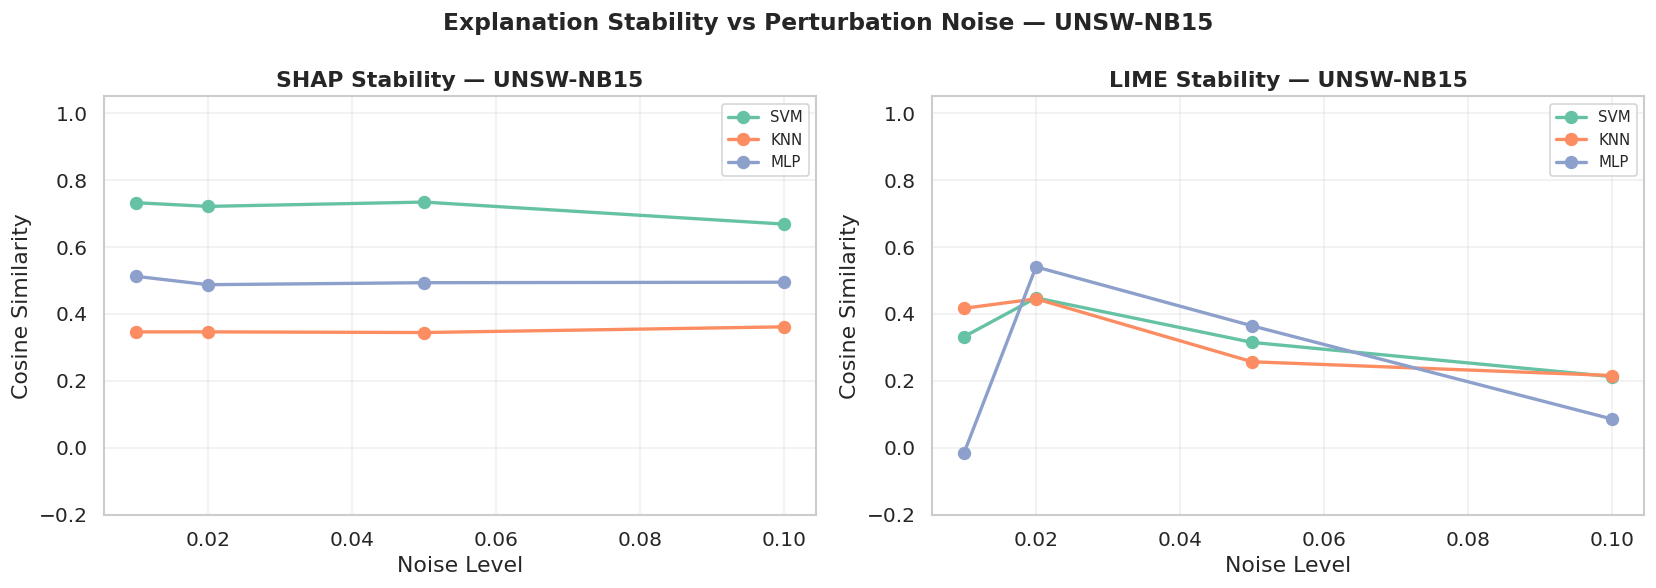

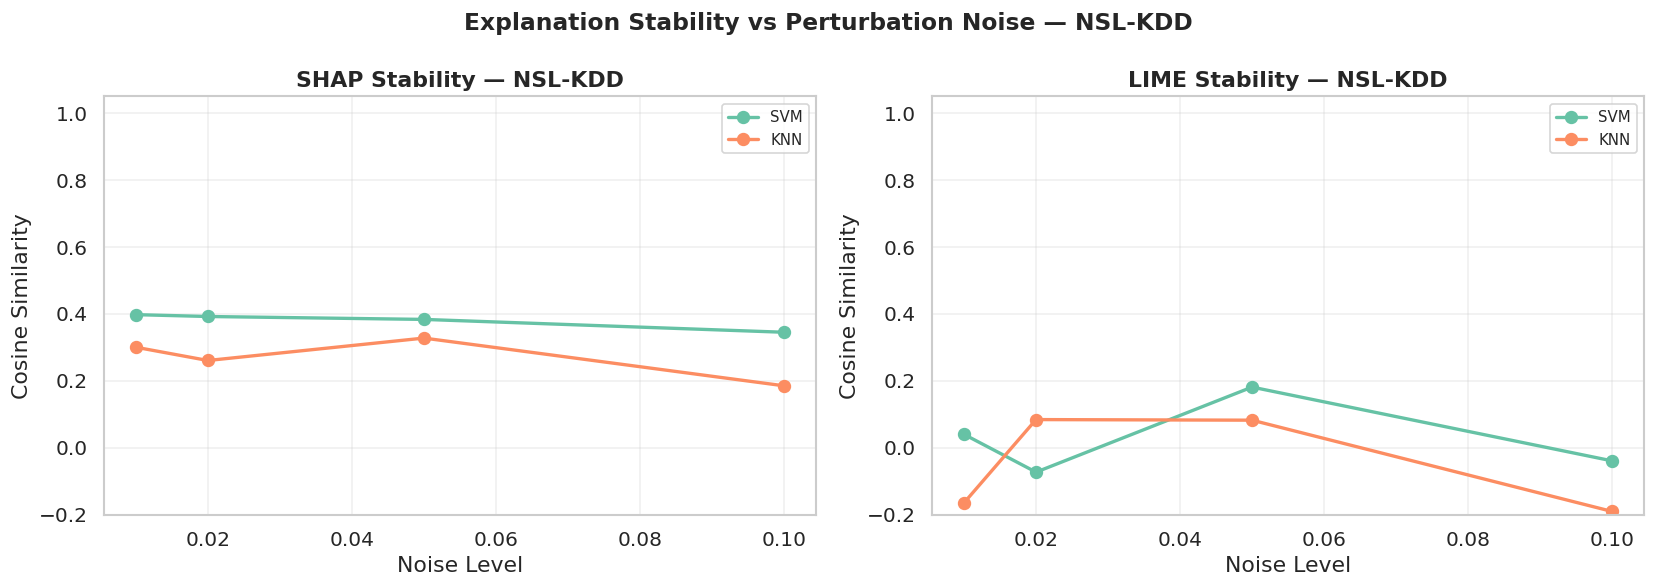

In [18]:
for ds_name in active_datasets:
    models_in_ds = stab_df[stab_df['Dataset']==ds_name]['Model'].unique().tolist()
    xai_methods  = ['SHAP', 'LIME']
    palette_ds   = sns.color_palette('Set2', len(models_in_ds))

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, xai in zip(axes, xai_methods):
        sub = stab_df[(stab_df['Dataset']==ds_name) & (stab_df['XAI']==xai)]
        for mi, mn in enumerate(models_in_ds):
            d = sub[sub['Model']==mn]
            if len(d) > 0:
                ax.plot(d['Noise'], d['Cosine'], marker='o',
                        label=mn, color=palette_ds[mi],
                        linewidth=2, markersize=7)
        ax.set_xlabel('Noise Level')
        ax.set_ylabel('Cosine Similarity')
        ax.set_title(f'{xai} Stability — {ds_name}', fontweight='bold')
        ax.legend(fontsize=9)
        ax.set_ylim(-0.2, 1.05)
        ax.grid(True, alpha=0.3)

    fig.suptitle(f'Explanation Stability vs Perturbation Noise — {ds_name}',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'results/extended_stability_noise_{ds_name.replace("-","_")}.png',
                bbox_inches='tight', dpi=120)
    plt.show()

### 5.2 Stability Heatmap at noise = 0.02

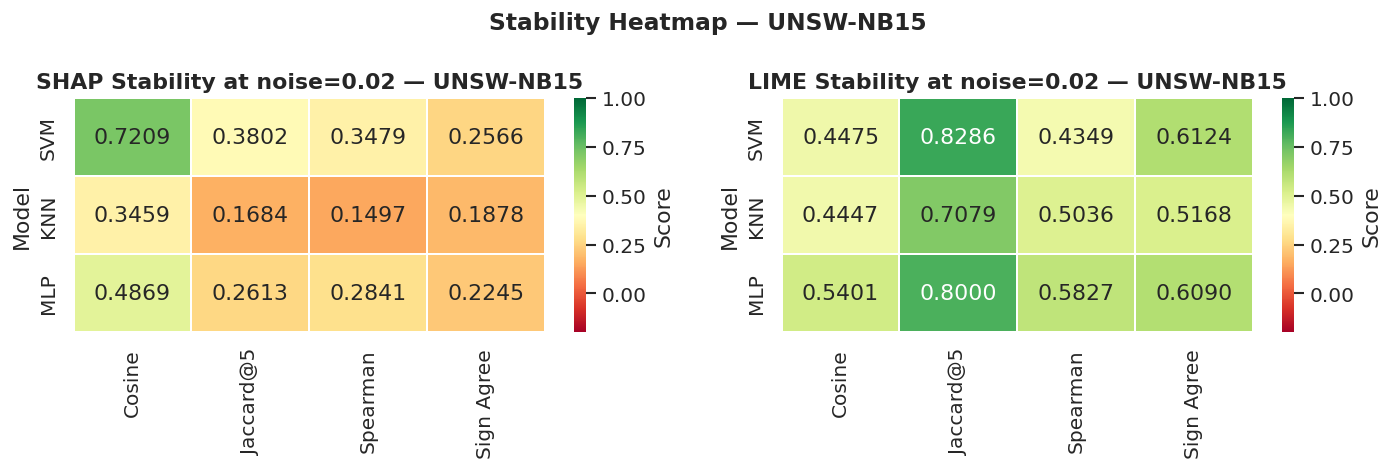

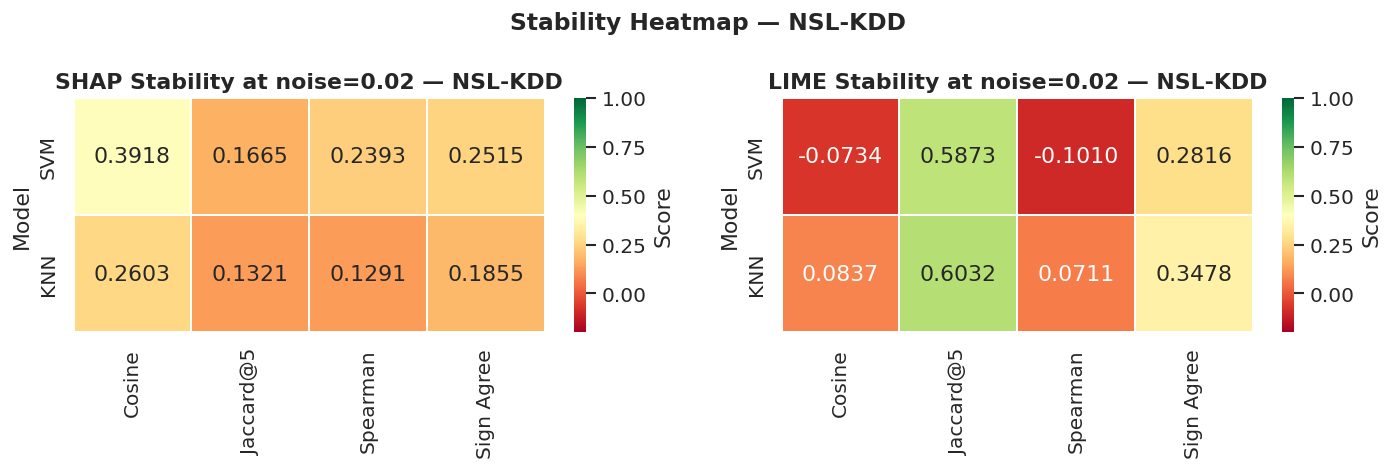

In [19]:
sub02 = stab_df[stab_df['Noise'] == 0.02]

for ds_name in active_datasets:
    models_in_ds = sub02[sub02['Dataset']==ds_name]['Model'].unique().tolist()
    if not models_in_ds:
        continue

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for ax, xai in zip(axes, ['SHAP', 'LIME']):
        sub = sub02[(sub02['Dataset']==ds_name) & (sub02['XAI']==xai)]
        if sub.empty:
            ax.set_visible(False)
            continue
        pivot = sub.pivot(index='Model', columns='XAI', values='Cosine')
        # build a single-column heatmap with model on y-axis
        data = sub.set_index('Model')[['Cosine','Jaccard@5','Spearman','Sign Agree']]
        sns.heatmap(data, annot=True, fmt='.4f', cmap='RdYlGn',
                    ax=ax, linewidths=1, vmin=-0.2, vmax=1.0,
                    cbar_kws={'label': 'Score'})
        ax.set_title(f'{xai} Stability at noise=0.02 — {ds_name}',
                     fontweight='bold')
        ax.set_xlabel('')

    fig.suptitle(f'Stability Heatmap — {ds_name}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'results/extended_stability_heatmap_{ds_name.replace("-","_")}.png',
                bbox_inches='tight', dpi=120)
    plt.show()

### 5.3 All Stability Metrics at noise = 0.02

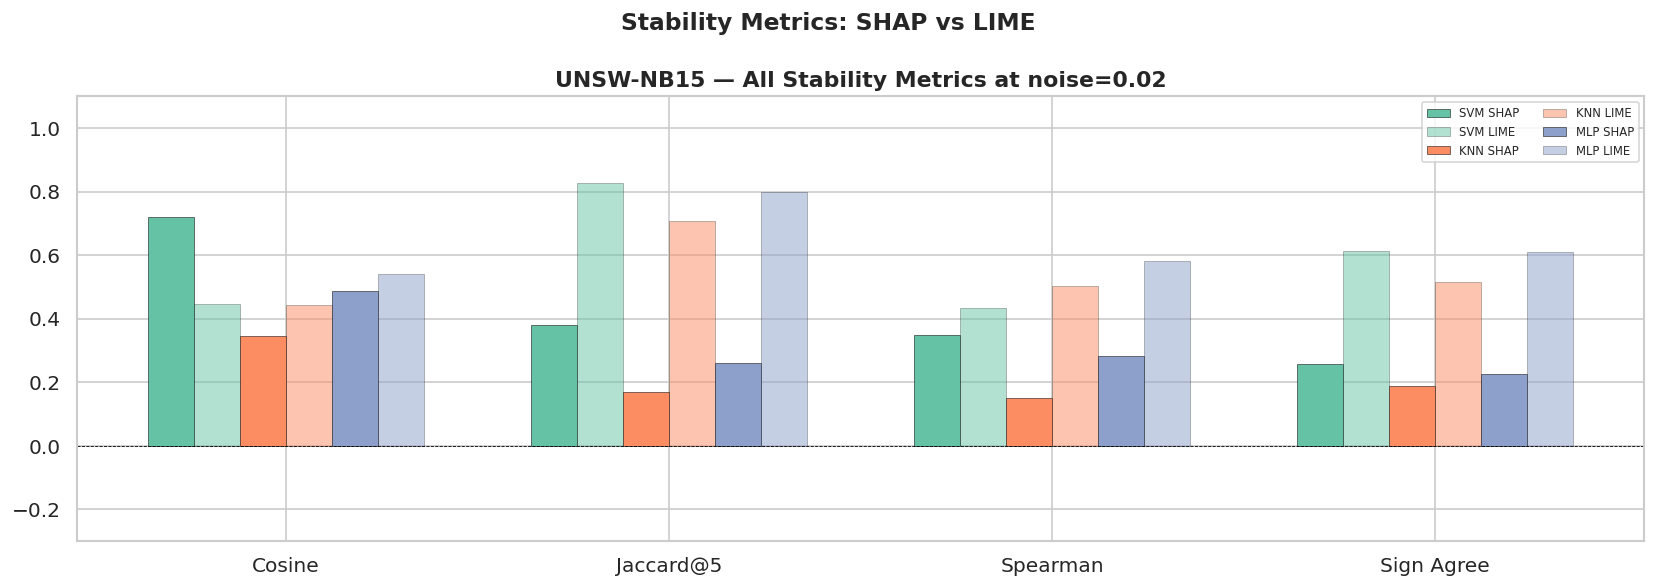

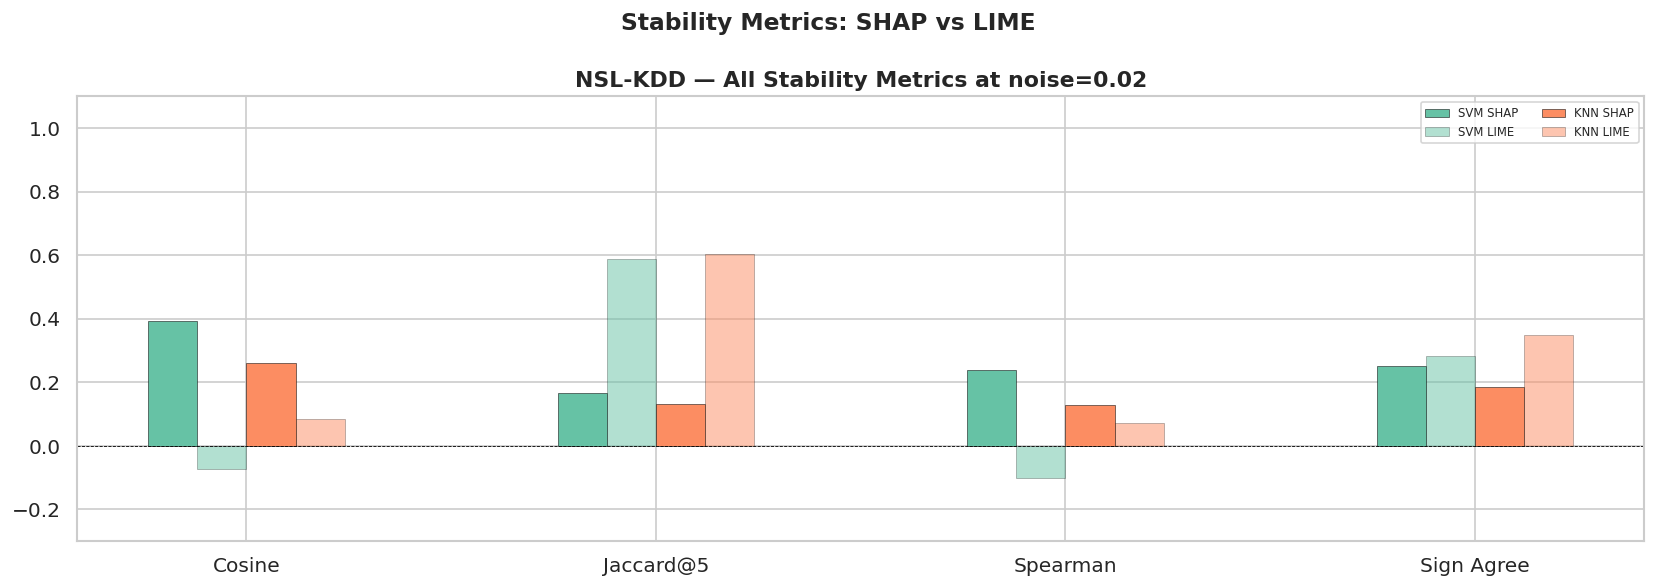

In [20]:
stab_met = ['Cosine', 'Jaccard@5', 'Spearman', 'Sign Agree']

for ds_name in active_datasets:
    sub = stab_df[(stab_df['Dataset']==ds_name) & (stab_df['Noise']==0.02)]
    if sub.empty:
        continue
    models_in_ds = sub['Model'].unique().tolist()
    palette_ds   = sns.color_palette('Set2', len(models_in_ds))

    fig, ax = plt.subplots(figsize=(14, 5))
    x   = np.arange(len(stab_met))
    w   = 0.12
    off = 0
    for mi, mn in enumerate(models_in_ds):
        for xai in ['SHAP', 'LIME']:
            row = sub[(sub['Model']==mn) & (sub['XAI']==xai)]
            if len(row) == 0:
                continue
            vals = [row[m].values[0] for m in stab_met]
            ax.bar(x + off*w, vals, w,
                   label=f'{mn} {xai}',
                   color=palette_ds[mi],
                   alpha=1.0 if xai=='SHAP' else 0.5,
                   edgecolor='black', linewidth=0.3)
            off += 1

    ax.set_xticks(x + (off/2 - 0.5) * w)
    ax.set_xticklabels(stab_met)
    ax.set_title(f'{ds_name} — All Stability Metrics at noise=0.02',
                 fontweight='bold')
    ax.set_ylim(-0.3, 1.1)
    ax.legend(fontsize=7, ncol=2, loc='upper right')
    ax.axhline(y=0, color='black', linewidth=0.5, linestyle='--')

    fig.suptitle('Stability Metrics: SHAP vs LIME', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'results/extended_stability_metrics_{ds_name.replace("-","_")}.png',
                bbox_inches='tight', dpi=120)
    plt.show()

## 6. Summary

In [21]:
display(HTML('<h4>1. Model Performance</h4>'))
display(perf_df.style
    .background_gradient(cmap='YlGnBu',
                         subset=['Accuracy','Precision','Recall','F1-Score'])
    .format({'Accuracy':'{:.4f}','Precision':'{:.4f}',
             'Recall':'{:.4f}','F1-Score':'{:.4f}'}))

display(HTML('<h4>2. SHAP vs LIME Feature Agreement</h4>'))
display(agree_df)

display(HTML('<h4>3. Stability at noise=0.02</h4>'))
display(stab_df[stab_df['Noise']==0.02].reset_index(drop=True))

print('\nAll results saved to results/')
for f in sorted(os.listdir('results')):
    if f.startswith('extended') and (f.endswith('.csv') or f.endswith('.png')):
        print(f'  results/{f}')

,Dataset,Model,Accuracy,Precision,Recall,F1-Score,Train Time (s)
0,UNSW-NB15,SVM,0.9375,0.9187,0.9963,0.9559,26.820000
1,UNSW-NB15,KNN,0.9377,0.9431,0.9668,0.9548,0.020000
2,UNSW-NB15,MLP,0.9451,0.9490,0.9715,0.9601,39.940000
3,NSL-KDD,SVM,0.7812,0.9760,0.6312,0.7666,11.170000
4,NSL-KDD,KNN,0.7724,0.9701,0.6192,0.7559,0.020000


,Dataset,Model,Top-10 Overlap,Jaccard,Spearman,SHAP Time (s),LIME Time (s)
0,UNSW-NB15,SVM,7,0.5385,0.2381,127.94,69.45
1,UNSW-NB15,KNN,6,0.4286,0.4364,98.83,56.20
2,UNSW-NB15,MLP,6,0.4286,0.3578,39.97,27.40
3,NSL-KDD,SVM,0,0.0000,-0.5328,64.58,31.61
4,NSL-KDD,KNN,2,0.1111,-0.3120,99.26,55.71


,Dataset,Model,XAI,Noise,Cosine,Jaccard@5,Spearman,Sign Agree
0,UNSW-NB15,SVM,SHAP,0.02,0.7209,0.3802,0.3479,0.2566
1,UNSW-NB15,SVM,LIME,0.02,0.4475,0.8286,0.4349,0.6124
2,UNSW-NB15,KNN,SHAP,0.02,0.3459,0.1684,0.1497,0.1878
3,UNSW-NB15,KNN,LIME,0.02,0.4447,0.7079,0.5036,0.5168
4,UNSW-NB15,MLP,SHAP,0.02,0.4869,0.2613,0.2841,0.2245
5,UNSW-NB15,MLP,LIME,0.02,0.5401,0.8000,0.5827,0.6090
6,NSL-KDD,SVM,SHAP,0.02,0.3918,0.1665,0.2393,0.2515
7,NSL-KDD,SVM,LIME,0.02,-0.0734,0.5873,-0.1010,0.2816
8,NSL-KDD,KNN,SHAP,0.02,0.2603,0.1321,0.1291,0.1855
9,NSL-KDD,KNN,LIME,0.02,0.0837,0.6032,0.0711,0.3478



All results saved to results/
  results/extended_agreement_NSL_KDD.png
  results/extended_agreement_UNSW_NB15.png
  results/extended_confusion_matrices.png
  results/extended_mlp_training_curves.png
  results/extended_model_performance.csv
  results/extended_performance_bars.png
  results/extended_shap_lime_bars_NSL_KDD.png
  results/extended_shap_lime_bars_UNSW_NB15.png
  results/extended_shap_summary_NSL_KDD.png
  results/extended_shap_summary_UNSW_NB15.png
  results/extended_stability_heatmap_NSL_KDD.png
  results/extended_stability_heatmap_UNSW_NB15.png
  results/extended_stability_metrics_NSL_KDD.png
  results/extended_stability_metrics_UNSW_NB15.png
  results/extended_stability_noise_NSL_KDD.png
  results/extended_stability_noise_UNSW_NB15.png
  results/extended_stability_results.csv
  results/extended_xai_agreement.csv
  results/extended_xai_runtime_NSL_KDD.png
  results/extended_xai_runtime_UNSW_NB15.png
